# RLVR Data Attribution Experiment

**Goal:** Measure how training on Math problems (via GRPO) influences the model's zero-shot reasoning on Code problems.

**Pipeline:**
1. Load model + LoRA adapters
2. Load Math (train) and Code (test) datasets
3. Fine-tune with GRPO on Math
4. Extract **SFT gradients** for Code test prompts ($g_{test}$)
5. Extract **RLVR gradients** for Math train prompts ($g_{train}$) — simulated GRPO step
6. Build the $N_{test} \times M_{train}$ influence matrix via TracIn

## 1. Hardware Detection & Model Initialization

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from influence_rlvr import detect_device, clear_cache

DEVICE = detect_device()
ENABLE_VLLM = DEVICE.type == "cuda"

def _clear():
    clear_cache(DEVICE)

print(f"Device: {DEVICE} | vLLM enabled: {ENABLE_VLLM}")

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
LEARNING_RATE = 1e-4

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
).to(DEVICE)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Device: mps | vLLM enabled: False


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 1,089,536 || all params: 1,544,803,840 || trainable%: 0.0705


## 2. Prepare Datasets

In [2]:
from datasets import load_dataset

# ── Z_train: Math (GSM8K) ────────────────────────────────────────────────
math_data = load_dataset("openai/gsm8k", "main", split="train[:50]")

def format_math(example):
    return {
        "prompt": [
            {"role": "system", "content": "You are a math reasoning assistant. Think inside <think> tags, then output your answer inside <answer> tags."},
            {"role": "user", "content": example["question"]}
        ],
        "solution": example["answer"].split("#### ")[-1]
    }

train_dataset = math_data.map(format_math)

# ── Z_test: Code (MBPP) ──────────────────────────────────────────────────
code_data = load_dataset("mbpp", split="test[:5]")

def format_code(example):
    return {
        "prompt": [
            {"role": "system", "content": "You are a coding assistant."},
            {"role": "user", "content": example["text"]}
        ],
        "solution": example["code"]
    }

test_dataset = code_data.map(format_code)

print(f"Z_train (Math): {len(train_dataset)} samples")
print(f"Z_test  (Code): {len(test_dataset)} samples")

Z_train (Math): 50 samples
Z_test  (Code): 5 samples


## 3. GRPO Training on Math

In [3]:
from trl import GRPOConfig, GRPOTrainer
from influence_rlvr.rewards import format_reward_func, accuracy_reward_func

training_args = GRPOConfig(
    output_dir="./rlvr-mac-sandbox",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    max_steps=10,
    logging_steps=2,
    bf16=True,
    use_vllm=False,
    num_generations=8,
    generation_batch_size=8,
)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[format_reward_func, accuracy_reward_func],
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

print("Starting GRPO Training...")
trainer.train()
clear_cache()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.
/Users/bui/anaconda3/envs/rlvr/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Starting GRPO Training...


Step,Training Loss
2,0.097983
4,-0.052609
6,-0.086624
8,0.086279
10,-0.064674


## 4. Data Attribution — Compute Gradients

**Key fix over the old pipeline:** Train gradients ($g_{train}$) are now extracted via a simulated GRPO step (generation → reward → advantage → policy loss), not SFT cross-entropy. Test gradients ($g_{test}$) remain SFT-based since we evaluate on fixed Code prompt/solution pairs.

In [4]:
import importlib
import influence_rlvr.gradients as _grad_mod

importlib.reload(_grad_mod)
from influence_rlvr.gradients import compute_sft_gradient, compute_rlvr_gradient

# ── g_test: Code test gradients (SFT) ────────────────────────────────────
# Pass the full chat prompt so the gradient is conditioned on the same
# system+user context the model sees during generation.
N_TEST = len(test_dataset)

print(f"Computing {N_TEST} test (Code) gradients via SFT...")
test_infos = []
for idx in range(N_TEST):
    prompt = test_dataset[idx]["prompt"]
    solution = test_dataset[idx]["solution"]
    g = compute_sft_gradient(model, tokenizer, prompt, solution, DEVICE)
    test_infos.append({
        "grad": g,
        "prompt": prompt,
        "solution": solution,
    })
    _clear()
    print(f"  g_test[{idx}] norm={g.norm().item():.6f}")

Computing 5 test (Code) gradients via SFT...
  g_test[0] norm=0.758915
  g_test[1] norm=2.479529
  g_test[2] norm=2.299143
  g_test[3] norm=2.286664
  g_test[4] norm=2.973809


In [5]:
from functools import partial
from influence_rlvr.rewards import soft_format_reward_func, soft_accuracy_reward_func

# ── g_train: Math train gradients (RLVR) ─────────────────────────────────
# Pass the full chat prompt and keep debug artifacts so we can inspect cases
# where all sampled completions receive the same reward and the GRPO signal
# collapses to zero.
N_TRAIN = min(10, len(train_dataset))
G = 8

print(f"Computing {N_TRAIN} train (Math) gradients via simulated GRPO (G={G})...")
train_infos = []
zero_train_cases = []
for idx in range(N_TRAIN):
    prompt = train_dataset[idx]["prompt"]
    sol = train_dataset[idx]["solution"]
    reward_fns = [
        soft_format_reward_func,
        partial(soft_accuracy_reward_func, solution=[sol] * G),
    ]
    g, debug = compute_rlvr_gradient(
        model, tokenizer, prompt, reward_fns,
        G=G, device=DEVICE, enable_vllm=ENABLE_VLLM,
        return_debug=True,
    )
    grad_norm = g.norm().item()
    train_infos.append({
        "grad": g,
        "prompt": prompt,
        "solution": sol,
        "debug": debug,
    })
    _clear()
    print(f"  g_train[{idx}] norm={grad_norm:.6f}")
    if grad_norm <= 1e-12:
        zero_train_cases.append(idx)
        print(f"    rewards={debug['total_rewards']}")
        print(f"    advantages={debug['advantages']}")
        print(f"    policy_loss={debug['policy_loss']:.6f}")

print(f"Zero-gradient train cases: {zero_train_cases}")


def inspect_train_case(idx):
    info = train_infos[idx]
    debug = info["debug"]
    print(f"Train case {idx}")
    print(f"Question: {info['prompt'][1]['content']}")
    print(f"Solution: {info['solution']}")
    print(f"Rewards: {debug['total_rewards']}")
    print(f"Advantages: {debug['advantages']}")
    print(f"Policy loss: {debug['policy_loss']:.6f}")
    for sample_idx, response in enumerate(debug["responses"]):
        print(f"\n--- sample {sample_idx} ---")
        for reward_name, scores in debug["reward_breakdown"].items():
            print(f"{reward_name}: {scores[sample_idx]}")
        print(response)


if zero_train_cases:
    print("\nRun inspect_train_case(zero_train_cases[0]) to inspect the first zero-gradient example.")

Computing 10 train (Math) gradients via simulated GRPO (G=8)...
  g_train[0] norm=26.042915
  g_train[1] norm=42.181896
  g_train[2] norm=39.467339
  g_train[3] norm=32.300758
  g_train[4] norm=68.410751
  g_train[5] norm=40.549580
  g_train[6] norm=35.633385
  g_train[7] norm=52.075504
  g_train[8] norm=59.123501
  g_train[9] norm=80.003624
Zero-gradient train cases: []


In [ ]:
inspect_train_case(1)


Train case 1
Question: Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?
Solution: 10
Rewards: [1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5]
Advantages: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Policy loss: -0.000000

--- sample 0 ---
soft_format_reward_func: 1.0
soft_accuracy_reward_func: 0.5
<think>
To calculate how much Weng earned from babysitting for 50 minutes yesterday, we need to follow these steps:

1. Convert the time from minutes to hours because her hourly rate is given in dollars per hour.
2. Multiply the number of hours by her hourly rate.

There are 60 minutes in one hour, so 50 minutes is equal to \( \frac{50}{60} = \frac{5}{6} \) hours.

Her hourly rate is $12, so:
\( \text{Earnings} = \left( \frac{5}{6} \right) \times \$12 \)

Now let's perform the calculation:
\( \text{Earnings} = \$12 \times \frac{5}{6} \)
\( \text{Earnings} = \$10 \)

Therefore, Weng earned $10 from babysitting for 50 minutes yesterday.
</t

## 5. First-Order (TracIn) Influence

In [6]:
import numpy as np
from influence_rlvr.attribution import TracInInfluence, InfluenceCalculator

calculator = InfluenceCalculator(TracInInfluence(learning_rate=LEARNING_RATE))
influence_matrix = calculator.compute_matrix(test_infos, train_infos)

np.set_printoptions(precision=6, suppress=False)
print(f"Influence Matrix shape: {influence_matrix.shape}")
print(f"  ({N_TEST} Code test × {N_TRAIN} Math train)")
print(f"  max |influence| = {np.abs(influence_matrix).max():.6e}\n")
print(influence_matrix)

Influence Matrix shape: (5, 10)
  (5 Code test × 10 Math train)
  max |influence| = 1.046984e-03

[[-5.630680e-05 -4.012098e-05 -3.126609e-06  8.168150e-06  2.029539e-04
  -5.603677e-05  4.693423e-05  1.399964e-04  1.925261e-05  1.450849e-04]
 [-6.298646e-05 -2.025102e-04 -9.735530e-05 -1.754487e-05  5.071021e-04
  -1.807508e-04 -5.749544e-05  2.069316e-04  3.975219e-04  1.330511e-04]
 [-9.910815e-05 -1.078973e-04 -3.230845e-05  1.786260e-05  7.320677e-04
   2.049184e-04  2.671556e-04  5.249787e-04  6.535507e-04  5.464886e-04]
 [-1.207210e-04 -4.687830e-04 -1.226324e-04  3.561574e-06  6.792679e-04
  -1.694257e-05  1.013907e-04  4.358077e-04  2.263873e-04  1.532815e-04]
 [-1.977882e-04 -1.073684e-06 -8.959071e-05 -1.444169e-04  1.046984e-03
   1.570017e-04  2.696757e-04  8.091068e-04  3.604146e-04  5.618036e-04]]


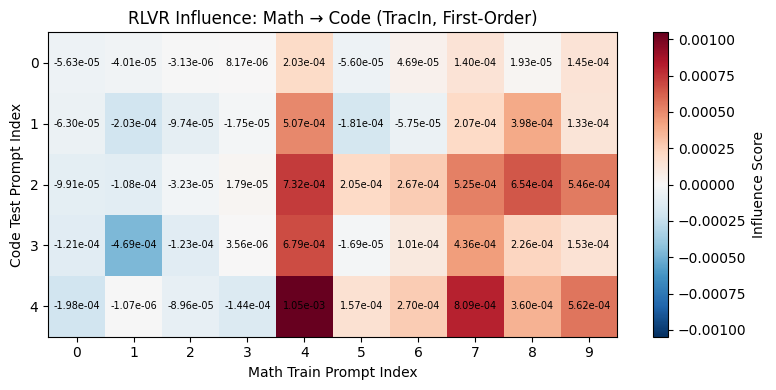

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(max(6, N_TRAIN * 0.8), max(3, N_TEST * 0.8)))
im = ax.imshow(influence_matrix, cmap="RdBu_r", aspect="auto",
               vmin=-np.abs(influence_matrix).max(),
               vmax=np.abs(influence_matrix).max())

ax.set_xlabel("Math Train Prompt Index")
ax.set_ylabel("Code Test Prompt Index")
ax.set_title("RLVR Influence: Math → Code (TracIn, First-Order)")
ax.set_xticks(range(N_TRAIN))
ax.set_yticks(range(N_TEST))
fig.colorbar(im, ax=ax, label="Influence Score")

for i in range(N_TEST):
    for j in range(N_TRAIN):
        ax.text(j, i, f"{influence_matrix[i, j]:.2e}",
                ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

## 6. Second-Order (DataInf / Proximal Bregman) Influence

Uses the Woodbury Matrix Identity to avoid ever instantiating the $D \times D$ Hessian.
The largest matrix inverted is $n \times n$ (number of training examples).

In [ ]:
import importlib
import influence_rlvr.attribution.datainf as _dinf_mod
importlib.reload(_dinf_mod)
from influence_rlvr.attribution import DataInfInfluence

LAMBDA_DAMP = 0.1

g_train_list = [info["grad"] for info in train_infos]
datainf = DataInfInfluence(g_train_list, lambda_damp=LAMBDA_DAMP, normalize=True)

influence_matrix_2nd = np.zeros((N_TEST, N_TRAIN))
for i in range(N_TEST):
    influence_matrix_2nd[i] = datainf.compute_all_scores(test_infos[i])

print(f"Second-Order Influence Matrix shape: {influence_matrix_2nd.shape}")
print(f"  max |influence| = {np.abs(influence_matrix_2nd).max():.6e}\n")
print(influence_matrix_2nd)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(12, N_TRAIN * 1.6), max(3, N_TEST * 0.8)))

for ax, mat, title in [
    (ax1, influence_matrix, "First-Order (TracIn)"),
    (ax2, influence_matrix_2nd, f"Second-Order (DataInf, λ={LAMBDA_DAMP})"),
]:
    vmax = np.abs(mat).max()
    im = ax.imshow(mat, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
    ax.set_xlabel("Math Train Prompt Index")
    ax.set_ylabel("Code Test Prompt Index")
    ax.set_title(title)
    ax.set_xticks(range(N_TRAIN))
    ax.set_yticks(range(N_TEST))
    fig.colorbar(im, ax=ax, label="Influence Score")
    for i in range(N_TEST):
        for j in range(N_TRAIN):
            ax.text(j, i, f"{mat[i, j]:.2e}",
                    ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()


## 7. Comparative Analysis

In [ ]:
for i in range(N_TEST):
    prompt_messages = test_dataset[i]["prompt"]
    code_prompt = prompt_messages[1]["content"]
    print(f"{'='*80}")
    print(f"Code[{i}]: \"{code_prompt[:80]}...\"")

    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True,
    )
    prompt_inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False).to(DEVICE)
    with torch.no_grad():
        generated = model.generate(
            input_ids=prompt_inputs["input_ids"],
            attention_mask=prompt_inputs["attention_mask"],
            max_new_tokens=256,
            do_sample=True, temperature=0.7, top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    model_answer = tokenizer.decode(
        generated[0][prompt_inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()
    print(f"  Model Answer:\n{model_answer}\n")

    for label, mat in [("TracIn (1st-Order)", influence_matrix),
                        ("DataInf (2nd-Order)", influence_matrix_2nd)]:
        row = mat[i]
        most_helpful = int(np.argmax(row))
        most_harmful = int(np.argmin(row))
        print(f"  [{label}]")
        print(f"    Most helpful: train[{most_helpful}] (score={row[most_helpful]:.4e})")
        print(f"      Math: \"{train_dataset[most_helpful]['prompt'][1]['content'][:80]}...\"")
        print(f"    Most harmful: train[{most_harmful}] (score={row[most_harmful]:.4e})")
        print(f"      Math: \"{train_dataset[most_harmful]['prompt'][1]['content'][:80]}...\"")

    h1 = int(np.argmax(influence_matrix[i]))
    h2 = int(np.argmax(influence_matrix_2nd[i]))
    ranking_changed = h1 != h2
    print(f"  Ranking changed? {'YES' if ranking_changed else 'No'}"
          f" (TracIn→{h1}, DataInf→{h2})")
    print()
